# Pipeline — April 13

Changes from `pipeline_apr7.ipynb`:
- **Removed 100 pc distance cut** — now runs on the full cleaned sample (~2000+ stars)
- **Removed `head(300)` cap** — Gaia is queried for all stars; results cached to disk so a restart doesn't re-query everything
- **Av hard cap raised 0.15 → 5.0 mag** — 0.15 was fine for nearby stars but cuts off physically valid extinction at larger distances. The Gaussian prior still keeps Av close to the ISM-expected value; the hard cap just prevents the sampler from hitting a wall.
- **Av clipping updated throughout** (find_mle seeds, walker init) to match new bound
- **Av warning threshold in diagnostics raised** to 1.0 mag (0.12 was a 100-pc-specific sanity check)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
from astroquery.gaia import Gaia
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
from isochrones.mist import MIST_Isochrone
import emcee
import astropy.units as u
from dust_extinction.parameter_averages import F99
from tqdm.notebook import tqdm

mist = MIST_Isochrone()

PyMultiNest not imported.  MultiNest fits will not work.


## 1. Helper Functions

In [2]:
def get_distance_info(ra, dec, radius=2/3600):
    """Query Gaia DR3 near (ra, dec). Returns (distance_pc, distance_err_pc)."""
    query = f"""
    SELECT TOP 1 parallax, parallax_error
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    AND parallax > 0
    """
    try:
        job = Gaia.launch_job(query)
        result = job.get_results()
    except Exception:
        return np.nan, np.nan
    if len(result) == 0:
        return np.nan, np.nan
    plx     = float(result['parallax'][0])
    plx_err = float(result['parallax_error'][0])
    if plx <= 0:
        return np.nan, np.nan
    dist_pc     = 1000.0 / plx
    dist_err_pc = 1000.0 * plx_err / plx**2
    return dist_pc, dist_err_pc


def apparent_to_absolute(m_app, distance_pc):
    return m_app - 5.0 * np.log10(distance_pc / 10.0)


def add_dist_err(phot_err, dist_pc, dist_err_pc):
    sigma_mu = 5.0 * dist_err_pc / (dist_pc * np.log(10))
    return np.sqrt(phot_err**2 + sigma_mu**2)

## 2. Load, Clean, and Merge Data

Keep all stars with complete photometry and spectroscopy — no distance cut.
Gaia parallax results are cached to `gaia_distances_cache.csv` so a notebook restart
doesn't re-query everything from scratch.

In [3]:
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Mega_Target_List.csv")
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")

df1 = df1.drop_duplicates(subset="hostname")
df2 = df2.drop_duplicates(subset="hostname")

merged = pd.merge(df1, df2, on="hostname", how="inner")
merged["ra"]  = merged["ra_x"]
merged["dec"] = merged["dec_x"]
merged = merged.drop(columns=[c for c in ["ra_x","ra_y","dec_x","dec_y","pl_name_y"] if c in merged.columns])

want_cols = [
    "hostname", "st_teff", "st_logg", "st_age", "st_met",
    "ra", "dec",
    "bj_dist_pc", "bj_dist_pc_lo", "bj_dist_pc_hi",   # Bailer-Jones distances
    "gaia_Gmag", "e_gaiamag",
    "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
    "e_Jmag", "e_Hmag", "e_Kmag",
]
merged = merged[[c for c in want_cols if c in merged.columns]]

merged = merged.dropna(subset=[
    "st_teff", "st_age", "st_met", "ra", "dec",
    "bj_dist_pc",
    "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
])

merged["e_gaiamag"] = merged["e_gaiamag"].fillna(0.01)
merged["e_Jmag"]    = merged["e_Jmag"].fillna(0.03)
merged["e_Hmag"]    = merged["e_Hmag"].fillna(0.03)
merged["e_Kmag"]    = merged["e_Kmag"].fillna(0.03)

# use Bailer-Jones distance; error = half the 84th-16th percentile range
merged["distance_pc"] = merged["bj_dist_pc"]
if "bj_dist_pc_hi" in merged.columns and "bj_dist_pc_lo" in merged.columns:
    merged["distance_err_pc"] = (merged["bj_dist_pc_hi"] - merged["bj_dist_pc_lo"]) / 2.0
else:
    merged["distance_err_pc"] = merged["bj_dist_pc"] * 0.05   # fallback: 5% if no error columns

merged_sample = merged.dropna(subset=["distance_pc"]).reset_index(drop=True)

print(f"Stars with complete data: {len(merged_sample)}")
print(f"  Distance range: {merged_sample['distance_pc'].min():.0f} – {merged_sample['distance_pc'].max():.0f} pc")
print(f"  Teff range:     {merged_sample['st_teff'].min():.0f} – {merged_sample['st_teff'].max():.0f} K")
display(HTML(merged_sample.head(10).to_html()))

Stars with complete data: 2817
  Distance range: 7 – 4635 pc
  Teff range:     2566 – 10170 K


,hostname,st_teff,st_logg,st_age,st_met,ra,dec,bj_dist_pc,bj_dist_pc_lo,bj_dist_pc_hi,gaia_Gmag,e_gaiamag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,distance_pc,distance_err_pc
0,HIP 65 A,4590.0,4.611,4.10,0.180,0.185606,-54.830823,61.778805,61.747059,61.816456,10.588468,0.000446,11.212916,9.835994,8.922,8.400,8.290,0.019,0.031,0.025,61.778805,0.034698
1,WASP-136,6250.0,3.900,3.62,-0.180,0.325761,-8.926251,266.452545,264.585419,268.203888,9.823880,0.000208,10.060003,9.431094,9.016,8.792,8.805,0.030,0.026,0.024,266.452545,1.809235
2,HATS-34,5380.0,4.435,7.70,0.250,0.774487,-62.469317,504.788971,502.074921,507.464142,13.666666,0.000279,14.053605,13.118170,12.513,12.139,12.095,0.024,0.022,0.019,504.788971,2.694611
3,WASP-96,5540.0,4.420,8.00,0.140,1.046570,-47.360635,347.290680,345.401398,349.274231,12.372176,0.000260,12.735786,11.849231,11.267,10.936,10.914,0.025,0.023,0.024,347.290680,1.936417
4,TOI-198,3650.0,4.750,5.30,-0.700,2.271509,-27.121745,23.763680,23.748178,23.778645,10.915721,0.000655,11.910542,9.930160,8.655,8.143,7.856,0.024,0.026,0.021,23.763680,0.015233
5,WASP-44,5420.0,4.494,10.30,-0.003,3.903273,-11.938265,358.446198,355.844177,360.427429,12.883635,0.000428,13.273107,12.335880,11.702,11.408,11.341,0.023,0.025,0.026,358.446198,2.291626
6,Gliese 12,3296.0,5.210,7.00,-0.320,3.957914,13.557617,12.161628,12.156276,12.166704,11.399355,0.001756,12.830511,10.227193,8.619,8.068,7.807,0.020,0.026,0.020,12.161628,0.005214
7,WASP-32,6140.0,4.400,2.22,-0.130,3.961707,1.200512,276.277100,273.121429,279.411804,11.409403,0.000750,11.692119,10.963176,10.503,10.248,10.161,0.022,0.028,0.023,276.277100,3.145187
8,WASP-158,6350.0,4.300,1.93,0.240,4.146347,-10.976423,530.449219,523.726807,536.904663,12.081388,0.000231,12.360909,11.643996,11.178,10.957,10.881,0.026,0.023,0.025,530.449219,6.588928
9,HD 1397,5521.0,3.823,4.51,0.290,4.447163,-66.358929,79.976562,79.898331,80.099846,7.605658,0.000278,7.984488,7.055598,6.442,6.090,5.988,0.020,0.049,0.018,79.976562,0.100758


## 3. Build MIST Interpolation Grid

In [4]:
age_grid  = np.linspace(6.0, 10.2, 60)
feh_grid  = np.linspace(-2.5,  0.5, 31)
mass_grid = np.linspace(0.1,  10.0, 200)

bands_interp = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {b: np.full(shape, np.nan) for b in bands_interp}

print("Building MIST grid (this takes a few minutes)...")
for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values("initial_mass")
        for b in bands_interp:
            if b not in iso.columns:
                continue
            cubes[b][i, j, :] = np.interp(
                mass_grid, iso["initial_mass"], iso[b],
                left=np.nan, right=np.nan
            )

interpolators = {}
for b in bands_interp:
    interpolators[b] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[b],
        bounds_error=False,
        fill_value=np.nan
    )

print("Done. Interpolators:", list(interpolators.keys()))

# solar sanity check
test = [[9.66, 0.0, 1.0]]
print(f"Solar check  G={interpolators['G_mag'](test)[0]:.2f}  "
      f"logg={interpolators['logg'](test)[0]:.2f}  "
      f"Teff={interpolators['Teff'](test)[0]:.0f} K")

Building MIST grid (this takes a few minutes)...
Done. Interpolators: ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
Solar check  G=4.55  logg=4.42  Teff=5847 K


## 4. Likelihood and Priors

**Av bounds**: hard cap raised to 5.0 mag (was 0.15). For stars within 100 pc the Gaussian
prior (centered at 0.7 mag/kpc × distance) already keeps Av small — the hard cap just
stops the sampler bouncing off a wall. For more distant stars (500–2000 pc), 0.15 was
completely wrong; 5.0 covers the realistic range.

In [5]:
ext_model = F99(Rv=3.1)

fit_bands = ["G", "BP", "RP", "J", "H", "K"]
band_map  = {"G": "G_mag", "BP": "BP_mag", "RP": "RP_mag",
             "J": "J_mag",  "H":  "H_mag",  "K":  "K_mag"}

band_wavelengths = {
    "G":  6231, "BP": 5323, "RP": 7725,
    "J":  12350, "H": 16620, "K": 21590,
}

ext_coeffs = {b: float(ext_model(band_wavelengths[b] * u.AA)) for b in fit_bands}
print("Extinction A(λ)/A(V):")
for b, c in ext_coeffs.items():
    print(f"  {b:3s}: {c:.4f}")

# systematic error floor for M-dwarfs (Teff < 4000K)
# RP (~7725Å): TiO bands not well modeled by MIST/Phoenix
# H (~1.66µm): H2O opacity wrong for cool atmospheres
MDWARF_TEFF_THRESHOLD = 4000
MDWARF_SYSTEMATIC     = {
    "G": 0.00, "BP": 0.00, "RP": 0.05,
    "J": 0.00, "H":  0.05, "K":  0.00,
}


def chi2_model(params, star):
    logage, mass, Av, feh = params
    feh_c = np.clip(feh, feh_grid.min(), feh_grid.max())
    pt = [[logage, feh_c, mass]]

    y    = np.array([star["photometry"][b] for b in fit_bands])
    yerr = np.array([star["phot_err"][b]   for b in fit_bands])

    if star["Teff"] < MDWARF_TEFF_THRESHOLD:
        yerr = np.sqrt(yerr**2 + np.array([MDWARF_SYSTEMATIC[b]**2 for b in fit_bands]))

    model_mags = np.array([interpolators[band_map[b]](pt)[0] for b in fit_bands])
    if np.any(np.isnan(model_mags)):
        return 1e10

    A_lambda       = np.array([ext_coeffs[b] * Av for b in fit_bands])
    model_mags_ext = model_mags + A_lambda

    chi2_phot = np.sum(((y - model_mags_ext) / yerr) ** 2)

    Teff_model = interpolators["Teff"](pt)[0]
    if np.isnan(Teff_model):
        return 1e10
    chi2_teff = ((star["Teff"] - Teff_model) / star["teff_err"]) ** 2

    chi2_logg = 0.0
    if not np.isnan(star["logg"]):
        logg_model = interpolators["logg"](pt)[0]
        if not np.isnan(logg_model):
            chi2_logg = ((star["logg"] - logg_model) / 0.2) ** 2

    return chi2_phot + chi2_teff + chi2_logg


def log_prior(params, star):
    logage, mass, Av, feh = params

    if not (6.0  <= logage <= 10.2):                   return -np.inf
    if not (0.1  <= mass   <= 2.5):                    return -np.inf
    if not (0.0  <= Av     <= 5.0):                    return -np.inf   # raised from 0.15
    if not (feh_grid.min() <= feh <= feh_grid.max()):  return -np.inf

    log_prior_age = 0.0

    if mass < 0.5:
        log_prior_mass = -1.3 * np.log(mass)
    else:
        log_prior_mass = -2.3 * np.log(mass)

    d         = star["distance_pc"]
    Av_expect = 0.0007 * d
    Av_sigma  = 0.02 + 0.0005 * d
    log_prior_Av = -0.5 * ((Av - Av_expect) / Av_sigma) ** 2

    log_prior_feh = -0.5 * ((feh - star["feh"]) / star["feh_err"]) ** 2

    return log_prior_age + log_prior_mass + log_prior_Av + log_prior_feh


def log_probability(params, star):
    lp = log_prior(params, star)
    if not np.isfinite(lp):
        return -np.inf
    return lp - 0.5 * chi2_model(params, star)

Extinction A(λ)/A(V):
  G  : 0.8214
  BP : 1.0247
  RP : 0.5865
  J  : 0.2620
  H  : 0.1633
  K  : 0.1121


## 5. Star Dictionary Builder

In [6]:
def init_mass_from_teff(teff):
    return float(np.clip((teff / 5778.0) ** 1.8, 0.15, 2.4))


def row_to_star(row):
    d     = float(row["distance_pc"])
    d_err = float(row.get("distance_err_pc", 0.0))
    if np.isnan(d_err):
        d_err = 0.0

    e_G  = max(float(row.get("e_gaiamag", 0.01)), 0.003)
    e_BP = max(e_G * 1.5, 0.015)
    e_RP = max(e_G * 1.2, 0.010)
    e_J  = max(float(row.get("e_Jmag", 0.03)), 0.01)
    e_H  = max(float(row.get("e_Hmag", 0.03)), 0.01)
    e_K  = max(float(row.get("e_Kmag", 0.03)), 0.01)

    phot_err = {
        "G":  add_dist_err(e_G,  d, d_err),
        "BP": add_dist_err(e_BP, d, d_err),
        "RP": add_dist_err(e_RP, d, d_err),
        "J":  add_dist_err(e_J,  d, d_err),
        "H":  add_dist_err(e_H,  d, d_err),
        "K":  add_dist_err(e_K,  d, d_err),
    }

    logg_val = row.get("st_logg", np.nan)
    logg_val = float(logg_val) if pd.notna(logg_val) else np.nan

    return {
        "hostname":    row["hostname"],
        "distance_pc": d,
        "photometry": {
            "G":  apparent_to_absolute(row["gaia_Gmag"],  d),
            "BP": apparent_to_absolute(row["gaia_BPmag"], d),
            "RP": apparent_to_absolute(row["gaia_RPmag"], d),
            "J":  apparent_to_absolute(row["Jmag"],       d),
            "H":  apparent_to_absolute(row["Hmag"],       d),
            "K":  apparent_to_absolute(row["Kmag"],       d),
        },
        "phot_err": phot_err,
        "Teff":     float(row["st_teff"]),
        "teff_err": 100.0,
        "logg":     logg_val,
        "feh":      float(row.get("st_met", 0.0)),
        "feh_err":  0.10,
        "age_true": float(row["st_age"]),
    }

## 6. Chi² Sanity Check

Run before any MCMC. If chi² at a reasonable starting point is huge, the likelihood has a bug.

In [7]:
solar_idx  = (merged_sample["st_teff"] - 5778).abs().idxmin()
solar_row  = merged_sample.loc[solar_idx]
solar_star = row_to_star(solar_row)

print(f"Sanity check star: {solar_star['hostname']}")
print(f"  Teff={solar_star['Teff']:.0f} K  logg={solar_star['logg']:.2f}  "
      f"[Fe/H]={solar_star['feh']:.2f}  d={solar_star['distance_pc']:.1f} pc")
print()

chi2_solar = chi2_model([9.66, 1.0, 0.001, 0.0], solar_star)
print(f"Chi2 at solar params (logage=9.66, M=1.0, Av=0.001, feh=0.0): {chi2_solar:.2f}")
print("  (should be < ~30 for a G-dwarf; if > 100 something is wrong)")
print()

print("Band  |  Observed Abs Mag  |  Model Mag  |  Diff")
print("-" * 52)
for b in fit_bands:
    obs   = solar_star["photometry"][b]
    model = interpolators[band_map[b]]([[9.66, 0.0, 1.0]])[0]
    print(f"  {b:3s}  |  {obs:+.3f}             |  {model:+.3f}     |  {obs-model:+.3f}")

Sanity check star: Kepler-1231
  Teff=5778 K  logg=4.44  [Fe/H]=0.06  d=954.6 pc

Chi2 at solar params (logage=9.66, M=1.0, Av=0.001, feh=0.0): 182.54
  (should be < ~30 for a G-dwarf; if > 100 something is wrong)

Band  |  Observed Abs Mag  |  Model Mag  |  Diff
----------------------------------------------------
  G    |  +4.803             |  +4.545     |  +0.257
  BP   |  +5.179             |  +4.849     |  +0.330
  RP   |  +4.260             |  +4.076     |  +0.184
  J    |  +3.651             |  +3.572     |  +0.079
  H    |  +3.339             |  +3.251     |  +0.088
  K    |  +3.276             |  +3.216     |  +0.060


## 7. MCMC Fitter

In [8]:
NWALKERS = 32
NSTEPS   = 8000
BURNIN   = 2000


def gelman_rubin(chain):
    """Split-chain R-hat. R-hat < 1.2 acceptable; < 1.1 ideal."""
    nsteps, nwalkers, ndim = chain.shape
    mid = nsteps // 2
    chains = np.concatenate([chain[:mid], chain[mid:]], axis=1)
    n  = chains.shape[0]
    m  = chains.shape[1]
    chain_means = chains.mean(axis=0)
    grand_mean  = chain_means.mean(axis=0)
    B = n / (m - 1) * ((chain_means - grand_mean) ** 2).sum(axis=0)
    W = ((chains - chain_means[None]) ** 2).sum(axis=(0, 1)) / (m * (n - 1))
    var_hat = (n - 1) / n * W + B / n
    rhat = np.sqrt(var_hat / (W + 1e-30))
    return rhat


def find_mle(star):
    d          = star["distance_pc"]
    mass_guess = init_mass_from_teff(star["Teff"])
    av_guess   = np.clip(0.0007 * d, 0.0, 4.99)   # ISM-expected Av, clipped to new bound
    seeds = [
        [9.0,  mass_guess,       av_guess,       star["feh"]],
        [8.0,  mass_guess,       av_guess,       star["feh"]],
        [7.5,  mass_guess * 0.9, min(av_guess * 2, 4.99), star["feh"]],
        [9.5,  mass_guess * 1.1, av_guess,       star["feh"]],
    ]
    best_p, best_val = None, np.inf
    for p0 in seeds:
        p0[0] = np.clip(p0[0], 6.1, 10.1)
        p0[1] = np.clip(p0[1], 0.11, 2.4)
        p0[2] = np.clip(p0[2], 0.0,  4.99)
        p0[3] = np.clip(p0[3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)
        if not np.isfinite(log_probability(p0, star)):
            continue
        try:
            res = minimize(
                lambda p: -log_probability(p, star), p0,
                method="Nelder-Mead",
                options={"maxiter": 3000, "xatol": 1e-4, "fatol": 1e-4},
            )
            if res.fun < best_val:
                best_val = res.fun
                best_p   = res.x
        except Exception:
            continue
    if best_p is None:
        best_p = np.array(seeds[0])
    best_p[0] = np.clip(best_p[0], 6.1, 10.1)
    best_p[1] = np.clip(best_p[1], 0.11, 2.4)
    best_p[2] = np.clip(best_p[2], 0.0,  4.99)
    best_p[3] = np.clip(best_p[3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)
    return best_p


def fit_star_emcee(star, nwalkers=NWALKERS, nsteps=NSTEPS, burnin=BURNIN):
    ndim = 4

    mle      = find_mle(star)
    mle_chi2 = chi2_model(mle, star)
    print(f"  MLE: logage={mle[0]:.2f}  mass={mle[1]:.3f}  "
          f"Av={mle[2]:.4f}  feh={mle[3]:.3f}  chi2={mle_chi2:.1f}")

    scale = np.array([0.05, 0.05, 0.002, 0.03])
    pos   = mle + scale * np.random.randn(nwalkers, ndim)
    pos[:, 0] = np.clip(pos[:, 0], 6.1, 10.1)
    pos[:, 1] = np.clip(pos[:, 1], 0.11, 2.4)
    pos[:, 2] = np.clip(pos[:, 2], 0.0,  4.99)
    pos[:, 3] = np.clip(pos[:, 3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability,
        args=(star,),
        moves=emcee.moves.StretchMove(a=1.5),
    )
    sampler.run_mcmc(pos, nsteps, progress=True)

    acc      = float(np.mean(sampler.acceptance_fraction))
    chain    = sampler.get_chain(discard=burnin)
    rhat     = gelman_rubin(chain)
    max_rhat = float(np.max(rhat))
    converged = bool(max_rhat < 1.2)
    print(f"  Acceptance: {acc:.3f}  |  Max R-hat: {max_rhat:.4f}  "
          f"({'OK' if converged else 'WARN >1.2'})  "
          f"R-hat per param: {np.round(rhat, 3)}")

    samples   = sampler.get_chain(discard=burnin, flat=True)
    age_samps = 10 ** samples[:, 0] / 1e9

    age_lo    = float(np.percentile(age_samps, 16))
    age_hi    = float(np.percentile(age_samps, 84))
    age_width = age_hi - age_lo
    unconstrained = bool(age_width > 5.0)

    # quality flag:
    # 0 = good
    # 1 = bad photometric fit or genuinely stuck chain
    # 2 = unconstrained flat posterior (MS star with no age info — not a failure)
    if mle_chi2 > 50 or acc < 0.10 or max_rhat > 2.0:
        quality = 1
    elif unconstrained:
        quality = 2
    else:
        quality = 0

    return {
        "hostname":       star["hostname"],
        "age_catalog":    star["age_true"],
        "age_median":     float(np.median(age_samps)),
        "age_err":        float(np.std(age_samps)),
        "age_lo":         age_lo,
        "age_hi":         age_hi,
        "age_width_68":   age_width,
        "mass_median":    float(np.median(samples[:, 1])),
        "mass_err":       float(np.std(samples[:, 1])),
        "Av_median":      float(np.median(samples[:, 2])),
        "feh_fitted":     float(np.median(samples[:, 3])),
        "acceptance":     acc,
        "max_rhat":       max_rhat,
        "mle_chi2":       mle_chi2,
        "converged":      converged,
        "unconstrained":  unconstrained,
        "quality":        quality,
        "distance_pc":    star["distance_pc"],
    }, samples

## 8. Run Pipeline — Full Sample

Saves after every star so a crash doesn't lose progress.
If you need to resume a partial run, load the checkpoint CSV and skip already-finished hostnames.

In [19]:
CHECKPOINT = "/Users/elenadickens/Desktop/ASTR_502/results_fullsample_checkpoint.csv"

# resume support: skip stars already in the checkpoint
if os.path.exists(CHECKPOINT):
    done_df   = pd.read_csv(CHECKPOINT)
    done_names = set(done_df["hostname"])
    results    = done_df.to_dict("records")
    print(f"Resuming — {len(done_names)} stars already done, {len(merged_sample) - len(done_names)} remaining")
else:
    done_names = set()
    results    = []
    print(f"Starting fresh — {len(merged_sample)} stars to run")

star_dicts  = [row_to_star(row) for _, row in merged_sample.iterrows()]
sample_list = [None] * len(star_dicts)   # filled in as we go

for i, star in enumerate(star_dicts):
    if star["hostname"] in done_names:
        continue

    print(f"\n[{i+1}/{len(star_dicts)}] {star['hostname']}  "
          f"Teff={star['Teff']:.0f} K  logg={star['logg']:.2f}  "
          f"d={star['distance_pc']:.1f} pc  [Fe/H]={star['feh']:.2f}")
    fit, samps = fit_star_emcee(star)
    results.append(fit)
    sample_list[i] = samps
    done_names.add(star["hostname"])

    pd.DataFrame(results).to_csv(CHECKPOINT, index=False)

results_df = pd.DataFrame(results)
print("\nAll done!")
display(HTML(results_df.to_html(index=False)))

Resuming — 2667 stars already done, 150 remaining

[2668/2817] Qatar-1  Teff=5013 K  logg=4.55  d=187.1 pc  [Fe/H]=0.17
  MLE: logage=7.78  mass=0.873  Av=0.1900  feh=0.210  chi2=8.7


100%|██████████| 8000/8000 [03:27<00:00, 38.62it/s]


  Acceptance: 0.414  |  Max R-hat: 1.2705  (WARN >1.2)  R-hat per param: [1.245 1.271 1.077 1.11 ]

[2669/2817] TOI-3523 A  Teff=6450 K  logg=4.17  d=603.7 pc  [Fe/H]=-0.37
  MLE: logage=9.64  mass=1.113  Av=0.4014  feh=-0.345  chi2=1.6


100%|██████████| 8000/8000 [02:49<00:00, 47.12it/s]


  Acceptance: 0.542  |  Max R-hat: 1.9055  (WARN >1.2)  R-hat per param: [1.177 1.905 1.118 1.033]

[2670/2817] WASP-74  Teff=5990 K  logg=4.39  d=148.7 pc  [Fe/H]=0.39
  MLE: logage=9.50  mass=1.302  Av=0.1548  feh=0.421  chi2=1.7


...

100%|██████████| 8000/8000 [02:35<00:00, 51.32it/s]


  Acceptance: 0.538  |  Max R-hat: 1.4524  (WARN >1.2)  R-hat per param: [1.237 1.452 1.042 1.192]

[2817/2817] WASP-8  Teff=5600 K  logg=4.50  d=89.9 pc  [Fe/H]=0.17
  MLE: logage=9.74  mass=0.988  Av=0.0618  feh=0.164  chi2=2.8


100%|██████████| 8000/8000 [02:44<00:00, 48.64it/s]


  Acceptance: 0.365  |  Max R-hat: 1.3772  (WARN >1.2)  R-hat per param: [1.377 1.337 1.071 1.155]

All done!


hostname,age_catalog,age_median,age_err,age_lo,age_hi,age_width_68,mass_median,mass_err,Av_median,feh_fitted,acceptance,max_rhat,mle_chi2,converged,unconstrained,quality,distance_pc
HIP 65 A,4.1000,0.281146,0.718716,0.106475,1.030801,0.924326,0.806792,0.009097,0.074845,0.302766,0.457605,1.232381,13.367472,False,False,0,61.778805
WASP-136,3.6200,2.603164,0.302120,2.384886,2.985989,0.601103,1.382234,0.052657,0.034332,-0.089714,0.349562,1.538195,7.612636,False,False,0,266.452545
HATS-34,7.7000,0.298704,1.109454,0.071123,1.493360,1.422237,1.014079,0.021878,0.041974,0.218384,0.518594,1.208994,0.871117,False,False,0,504.788971
WASP-96,8.0000,4.970108,2.630760,2.106202,7.633892,5.527690,1.035539,0.058131,0.091042,0.211372,0.441910,1.857177,2.843748,False,True,2,347.290680
TOI-198,5.3000,0.022542,0.005951,0.017447,0.029495,0.012047,0.262253,0.032801,0.018242,-0.646513,0.553746,1.168817,21.658624,True,False,0,23.763680
WASP-44,10.3000,0.886025,2.051134,0.128969,3.731513,3.602543,0.997580,0.035346,0.109416,0.101161,0.469020,1.190679,8.850714,True,False,0,358.446198
Gliese 12,7.0000,1.296331,2.977867,0.331867,5.681884,5.350017,0.257173,0.005110,0.009086,0.011856,0.432102,1.369652,19.438121,False,True,2,12.161628
WASP-32,2.2200,0.395303,1.453834,0.024843,2.615968,2.591125,1.144523,0.053206,0.136841,-0.044871,0.382926,1.316370,1.403975,False,False,0,276.277100
WASP-158,1.9300,1.554340,0.722332,0.732171,2.222691,1.490520,1.390187,0.054941,0.236485,0.288169,0.604723,1.386270,0.855438,False,False,0,530.449219
HD 1397,4.5100,4.150843,1.333838,3.681003,5.330277,1.649275,1.339285,0.152403,0.069291,0.222292,0.140672,3.549087,1.497134,False,False,1,79.976562


## 9. Convergence Summary

In [20]:
n_conv    = results_df["converged"].sum()
n_unconst = results_df["unconstrained"].sum()
n_total   = len(results_df)
print(f"Converged (R-hat < 1.2):       {n_conv} / {n_total}")
print(f"Unconstrained (width > 5 Gyr): {n_unconst} / {n_total}  — flat MS posteriors, expected")
print()

print("Quality flag summary:")
for q, desc in [(0, "Good"), (1, "Bad fit / non-convergence"), (2, "Unconstrained")]:
    print(f"  q={q} {desc}: {(results_df['quality']==q).sum()}")
print()

diag_cols = ["hostname", "distance_pc", "acceptance", "max_rhat", "converged", "age_width_68", "unconstrained", "quality"]
print(results_df[diag_cols].round(3).to_string(index=False))
print()

low_acc = results_df[results_df["acceptance"] < 0.20]
if len(low_acc):
    print("Low acceptance (<0.20):")
    print(low_acc[["hostname", "acceptance"]].to_string(index=False))

# Av sanity check — flag stars where fitted Av is unexpectedly high
# threshold is now 1.0 mag (was 0.12, which only made sense for <100 pc stars)
av_warn = results_df[results_df["Av_median"] > 1.0]
if len(av_warn):
    print("\nAv_median > 1.0 mag — check for possible extinction/age degeneracy:")
    print(av_warn[["hostname", "distance_pc", "age_catalog", "age_median", "Av_median"]].to_string(index=False))

Converged (R-hat < 1.2):       1336 / 2817
Unconstrained (width > 5 Gyr): 351 / 2817  — flat MS posteriors, expected

Quality flag summary:
  q=0 Good: 2245
  q=1 Bad fit / non-convergence: 266
  q=2 Unconstrained: 306

        hostname  distance_pc  acceptance  max_rhat  converged  age_width_68  unconstrained  quality
        HIP 65 A       61.779       0.458     1.232      False         0.924          False        0
        WASP-136      266.453       0.350     1.538      False         0.601          False        0
         HATS-34      504.789       0.519     1.209      False         1.422          False        0
         WASP-96      347.291       0.442     1.857      False         5.528           True        2
         TOI-198       23.764       0.554     1.169       True         0.012          False        0
         WASP-44      358.446       0.469     1.191       True         3.603          False        0
       Gliese 12       12.162       0.432     1.370      False         5.

## 10. Chi² Failure Diagnosis

In [21]:
CHI2_THRESHOLD = 50

failures = results_df[results_df["mle_chi2"] > CHI2_THRESHOLD].sort_values("mle_chi2", ascending=False)
print(f"{len(failures)} stars with MLE chi² > {CHI2_THRESHOLD}:\n")

star_lookup = {s["hostname"]: s for s in star_dicts}

for _, row in failures.iterrows():
    name = row["hostname"]
    star = star_lookup[name]

    mle = find_mle(star)
    pt  = [[mle[0], np.clip(mle[3], feh_grid.min(), feh_grid.max()), mle[1]]]

    model_mags = {b: float(interpolators[band_map[b]](pt)[0]) for b in fit_bands}
    A_lambda   = {b: ext_coeffs[b] * mle[2] for b in fit_bands}
    Teff_model = float(interpolators["Teff"](pt)[0])
    logg_model = float(interpolators["logg"](pt)[0])

    chi2_per_band = {}
    for b in fit_bands:
        obs  = star["photometry"][b]
        pred = model_mags[b] + A_lambda[b]
        err  = star["phot_err"][b]
        chi2_per_band[b] = ((obs - pred) / err) ** 2

    chi2_phot  = sum(chi2_per_band.values())
    chi2_teff  = ((star["Teff"] - Teff_model) / star["teff_err"]) ** 2
    chi2_logg  = ((star["logg"] - logg_model) / 0.2) ** 2 if not np.isnan(star["logg"]) else 0.0
    chi2_total = chi2_phot + chi2_teff + chi2_logg

    print(f"{'='*62}")
    print(f"  {name}   chi²_total={chi2_total:.1f}")
    print(f"  Teff={star['Teff']:.0f}K  logg={star['logg']:.2f}  "
          f"[Fe/H]={star['feh']:.2f}  d={star['distance_pc']:.1f}pc")
    print(f"  MLE: logage={mle[0]:.2f} ({10**mle[0]/1e9:.2f} Gyr)  "
          f"mass={mle[1]:.3f} Msun  Av={mle[2]:.4f}  feh={mle[3]:.3f}")
    print(f"  chi² breakdown:  phot={chi2_phot:.1f}  Teff={chi2_teff:.1f}  logg={chi2_logg:.1f}")
    print(f"  Model at MLE:  Teff={Teff_model:.0f}K  logg={logg_model:.2f}")
    print()
    print(f"  {'Band':>4}  {'Obs':>8}  {'Model+Av':>10}  {'Obs-Model':>10}  "
          f"{'Error':>7}  {'chi2':>8}  flag")
    print(f"  {'-'*62}")
    for b in fit_bands:
        obs  = star["photometry"][b]
        pred = model_mags[b] + A_lambda[b]
        err  = star["phot_err"][b]
        diff = obs - pred
        c2   = chi2_per_band[b]
        flag = "***" if c2 > 10 else ""
        print(f"  {b:>4}  {obs:>8.3f}  {pred:>10.3f}  {diff:>+10.3f}  "
              f"{err:>7.4f}  {c2:>8.1f}  {flag}")
    print()

58 stars with MLE chi² > 50:

  TRAPPIST-1   chi²_total=111577.9
  Teff=2566K  logg=5.24  [Fe/H]=0.05  d=12.5pc
  MLE: logage=9.48 (3.02 Gyr)  mass=0.150 Msun  Av=0.0265  feh=0.395
  chi² breakdown:  phot=111577.0  Teff=0.1  logg=0.8
  Model at MLE:  Teff=2602K  logg=5.06

  Band       Obs    Model+Av   Obs-Model    Error      chi2  flag
  --------------------------------------------------------------
     G    15.146      14.082      +1.064   0.0036   88311.1  ***
    BP    18.529      17.154      +1.376   0.0151    8268.6  ***
    RP    13.627      12.709      +0.918   0.0102    8122.8  ***
     J    10.877       9.761      +1.116   0.0221    2555.2  ***
     H    10.241       9.166      +1.075   0.0211    2600.2  ***
     K     9.819       8.862      +0.957   0.0231    1719.2  ***

  SPECULOOS-3   chi²_total=8952.3
  Teff=2800K  logg=5.26  [Fe/H]=0.07  d=16.7pc
  MLE: logage=8.85 (0.70 Gyr)  mass=0.150 Msun  Av=0.0031  feh=0.400
  chi² breakdown:  phot=8947.4  Teff=3.8  logg=1.1
  M

## 11. Results Plots

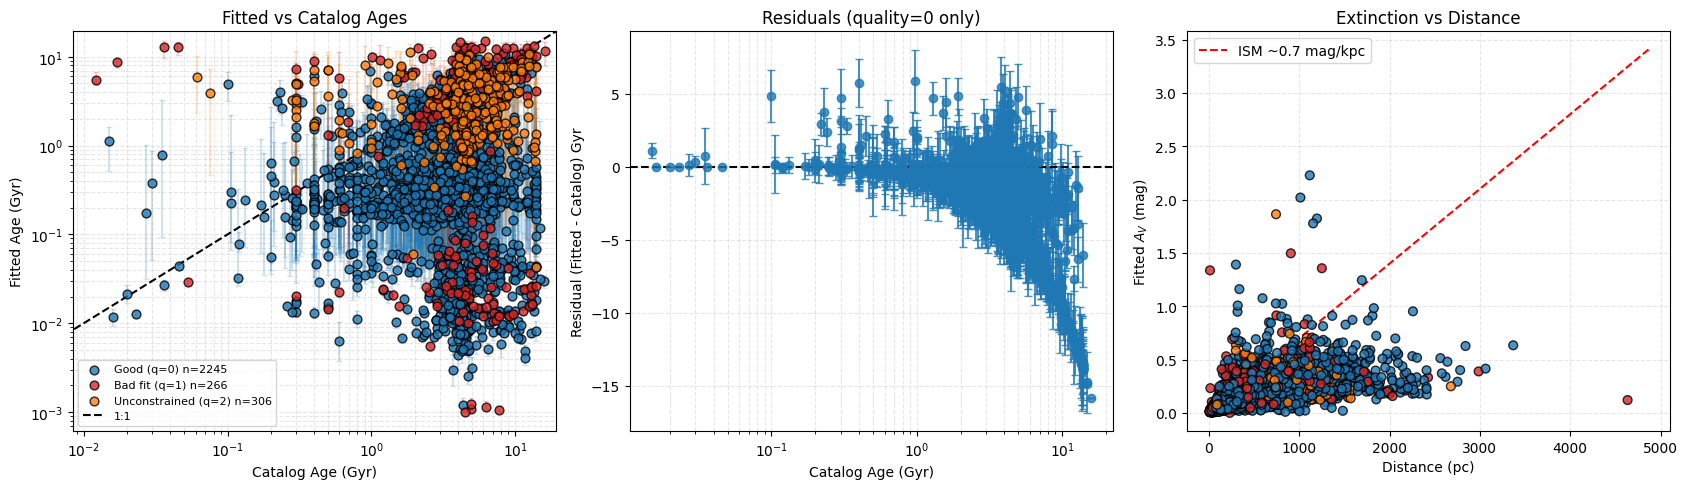

Quality flag summary:
  q=0 Good: 2245
  q=1 Bad fit / non-convergence: 266
  q=2 Unconstrained: 306


In [22]:
df = results_df.copy()
df["residual"]     = df["age_median"] - df["age_catalog"]
df["abs_residual"] = df["residual"].abs()

min_val = min(df["age_catalog"].min(), df["age_median"].min()) * 0.8
max_val = max(df["age_catalog"].max(), df["age_median"].max()) * 1.2
lims = [min_val, max_val]

quality_colors = {0: "tab:blue", 1: "tab:red", 2: "tab:orange"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# panel 1: fitted vs catalog
ax = axes[0]
for q, label, c in [(0, "Good (q=0)", "tab:blue"),
                    (1, "Bad fit (q=1)", "tab:red"),
                    (2, "Unconstrained (q=2)", "tab:orange")]:
    sub = df[df["quality"] == q]
    if len(sub) == 0:
        continue
    ax.scatter(sub["age_catalog"], sub["age_median"],
               color=c, s=40, edgecolor="k", zorder=3, label=f"{label} n={len(sub)}", alpha=0.8)
    ax.errorbar(sub["age_catalog"], sub["age_median"],
                yerr=[sub["age_median"] - sub["age_lo"], sub["age_hi"] - sub["age_median"]],
                fmt="none", color=c, alpha=0.2, capsize=2)
ax.plot(lims, lims, "k--", lw=1.5, label="1:1")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims);    ax.set_ylim(lims)
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Fitted Age (Gyr)")
ax.set_title("Fitted vs Catalog Ages")
ax.legend(fontsize=8); ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 2: residuals (quality=0 only)
ax = axes[1]
good = df[df["quality"] == 0]
ax.errorbar(good["age_catalog"], good["residual"],
            yerr=good["age_err"], fmt="o", capsize=3, alpha=0.8, color="tab:blue")
ax.axhline(0, color="k", ls="--", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Residual (Fitted - Catalog) Gyr")
ax.set_title("Residuals (quality=0 only)")
ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 3: Av vs distance
ax = axes[2]
ax.scatter(df["distance_pc"], df["Av_median"],
           c=df["quality"].map(quality_colors),
           edgecolor="k", s=40, zorder=3, alpha=0.8)
d_max   = df["distance_pc"].max() * 1.05
d_range = np.linspace(0, d_max, 200)
ax.plot(d_range, 0.0007 * d_range, "r--", label="ISM ~0.7 mag/kpc")
ax.set_xlabel("Distance (pc)")
ax.set_ylabel(r"Fitted $A_V$ (mag)")
ax.set_title("Extinction vs Distance")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
os.makedirs("/Users/elenadickens/Desktop/ASTR_502/plots", exist_ok=True)
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/pipeline_apr13_fullsample.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Quality flag summary:")
for q, desc in [(0, "Good"), (1, "Bad fit / non-convergence"), (2, "Unconstrained")]:
    print(f"  q={q} {desc}: {(df['quality']==q).sum()}")

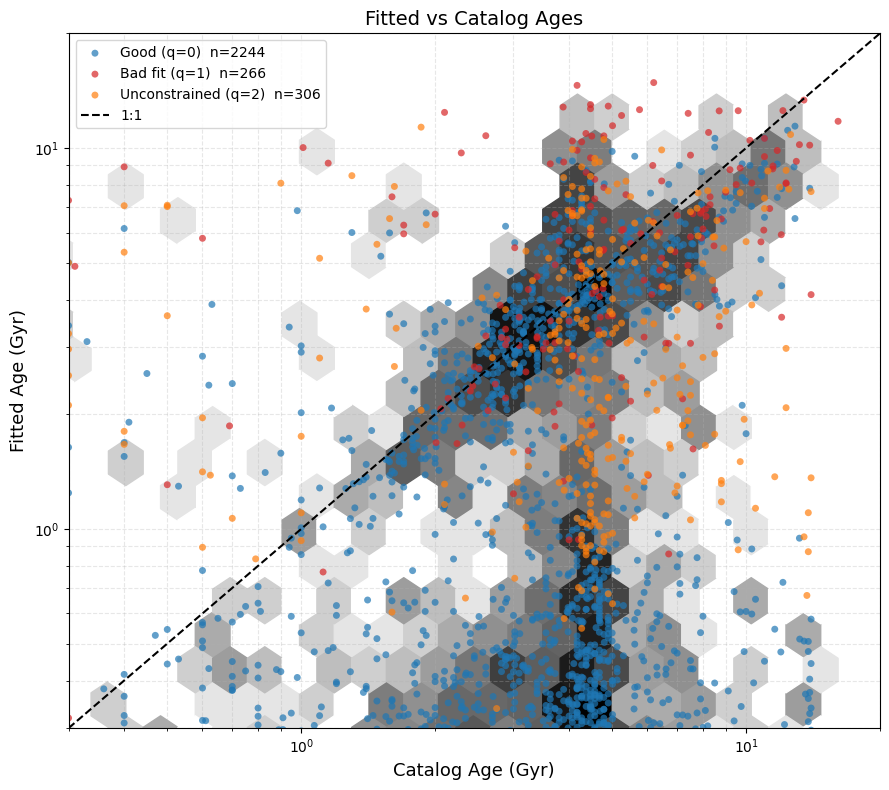

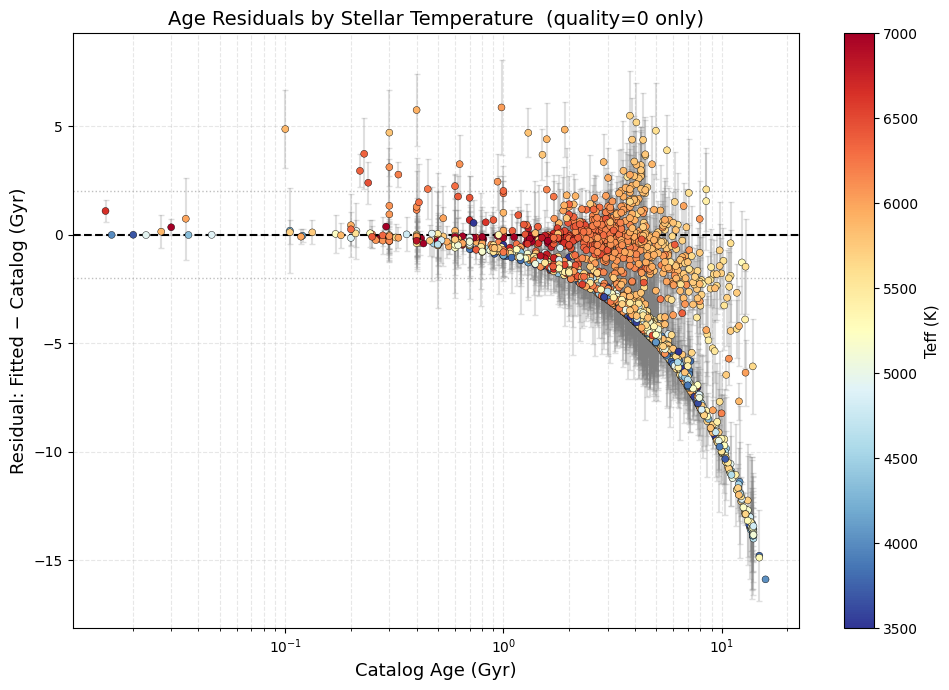

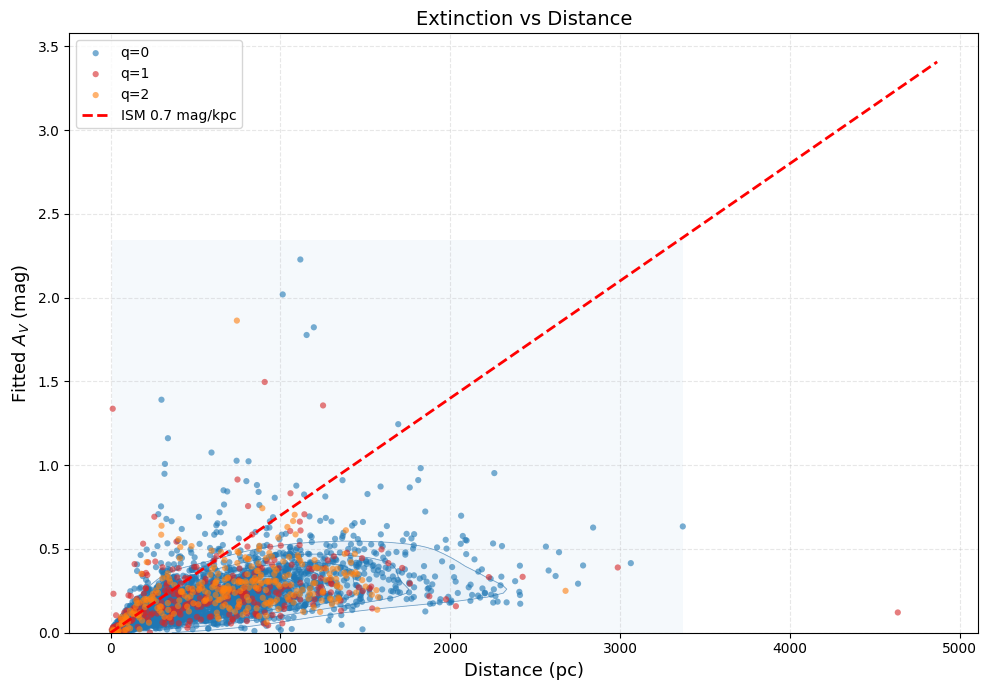

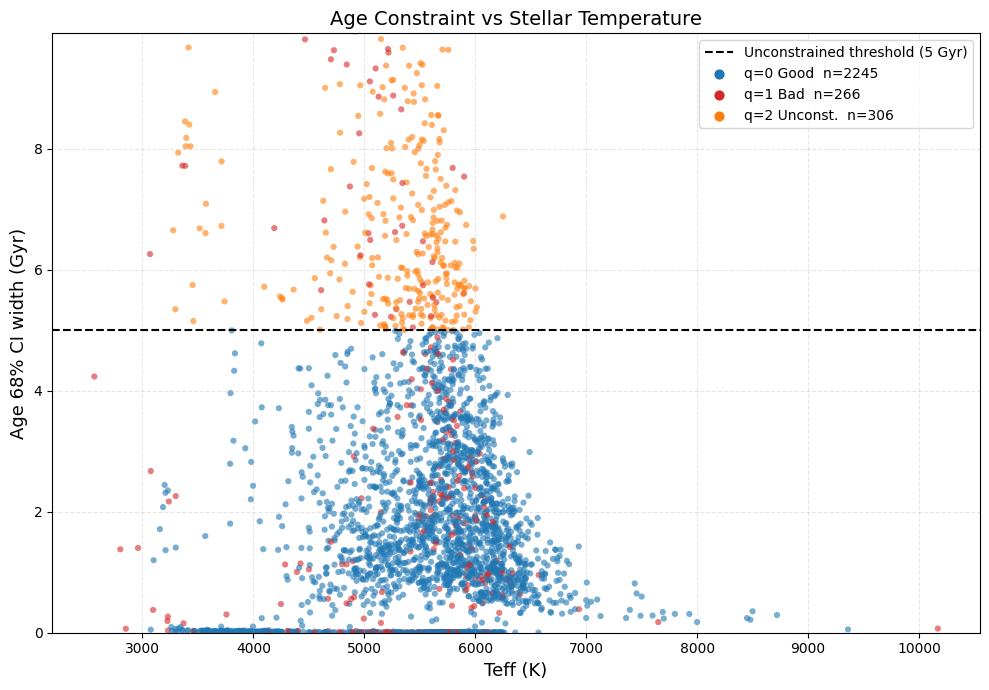

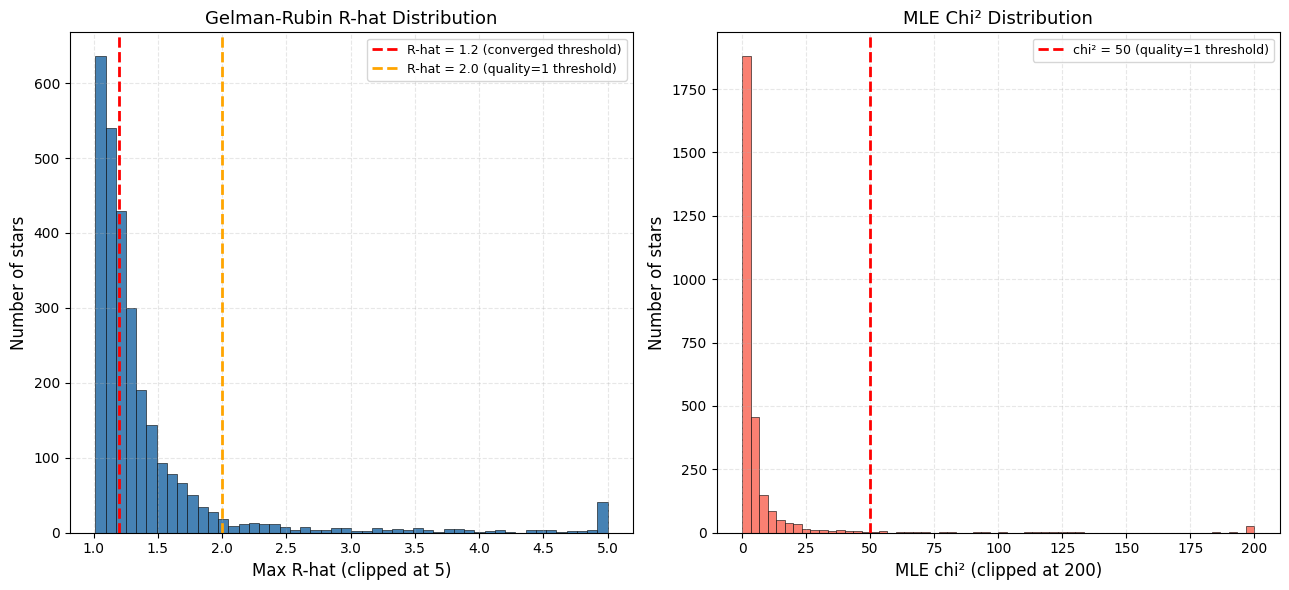

In [29]:
# ── Enhanced Results Plots ────────────────────────────────────────────────────
df = results_df.copy()
df["residual"]     = df["age_median"] - df["age_catalog"]
df["abs_residual"] = df["residual"].abs()

quality_colors = {0: "tab:blue", 1: "tab:red", 2: "tab:orange"}
good  = df[df["quality"] == 0]
bad   = df[df["quality"] == 1]
unconst = df[df["quality"] == 2]

# attach Teff from merged_sample for coloring
teff_map = merged_sample.set_index("hostname")["st_teff"]
df["Teff"] = df["hostname"].map(teff_map)

# ── Plot 1: Fitted vs Catalog — hexbin density + quality scatter ──────────────
fig, ax = plt.subplots(figsize=(9, 8))

lims = [0.3, 20]

# hexbin requires all values > 0 when log-scaled
df_pos = df[(df["age_catalog"] > 0) & (df["age_median"] > 0)]
ax.hexbin(df_pos["age_catalog"], df_pos["age_median"],
          gridsize=40, cmap="Greys", bins="log",
          xscale="log", yscale="log", mincnt=1, zorder=1)

for sub, label, c in [(good, "Good (q=0)", "tab:blue"),
                      (bad,  "Bad fit (q=1)", "tab:red"),
                      (unconst, "Unconstrained (q=2)", "tab:orange")]:
    if len(sub) == 0: continue
    sub_pos = sub[(sub["age_catalog"] > 0) & (sub["age_median"] > 0)]
    ax.scatter(sub_pos["age_catalog"], sub_pos["age_median"],
               color=c, s=25, edgecolor="none", alpha=0.7, zorder=2, label=f"{label}  n={len(sub_pos)}")

ax.plot(lims, lims, "k--", lw=1.5, label="1:1", zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims);    ax.set_ylim(lims)
ax.set_xlabel("Catalog Age (Gyr)", fontsize=13)
ax.set_ylabel("Fitted Age (Gyr)", fontsize=13)
ax.set_title("Fitted vs Catalog Ages", fontsize=14)
ax.legend(fontsize=10); ax.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/p1_age_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Residuals colored by Teff ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(good["age_catalog"], good["residual"],
                c=good["hostname"].map(teff_map),
                cmap="RdYlBu_r", s=25, edgecolor="k", linewidths=0.3,
                vmin=3500, vmax=7000, zorder=3)
ax.errorbar(good["age_catalog"], good["residual"],
            yerr=good["age_err"], fmt="none", color="gray", alpha=0.25, capsize=2, zorder=2)
ax.axhline(0, color="k", ls="--", lw=1.5)
ax.axhline( 2, color="gray", ls=":", lw=1, alpha=0.5)
ax.axhline(-2, color="gray", ls=":", lw=1, alpha=0.5)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Teff (K)", fontsize=11)
ax.set_xscale("log")
ax.set_xlabel("Catalog Age (Gyr)", fontsize=13)
ax.set_ylabel("Residual: Fitted − Catalog (Gyr)", fontsize=13)
ax.set_title("Age Residuals by Stellar Temperature  (quality=0 only)", fontsize=14)
ax.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/p2_residuals_teff.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Av vs Distance — contour density + ISM line ──────────────────────
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 7))

# KDE contour over all quality=0 stars
x = good["distance_pc"].values
y = good["Av_median"].values
mask = np.isfinite(x) & np.isfinite(y)
if mask.sum() > 10:
    kde  = gaussian_kde(np.vstack([np.log10(x[mask]+1), y[mask]]))
    xi   = np.linspace(np.log10(x[mask].min()+1), np.log10(x[mask].max()+1), 100)
    yi   = np.linspace(0, y[mask].max() * 1.05, 100)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi   = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    ax.contourf(10**Xi, Yi, Zi, levels=8, cmap="Blues", alpha=0.5, zorder=1)
    ax.contour( 10**Xi, Yi, Zi, levels=8, colors="steelblue", linewidths=0.6, alpha=0.7, zorder=2)

for sub, label, c in [(good, "q=0", "tab:blue"),
                      (bad,  "q=1", "tab:red"),
                      (unconst, "q=2", "tab:orange")]:
    if len(sub) == 0: continue
    ax.scatter(sub["distance_pc"], sub["Av_median"],
               color=c, s=20, edgecolor="none", alpha=0.6, zorder=3, label=label)

d_range = np.linspace(0, df["distance_pc"].max() * 1.05, 300)
ax.plot(d_range, 0.0007 * d_range, "r--", lw=2, label="ISM 0.7 mag/kpc", zorder=4)
ax.set_xlabel("Distance (pc)", fontsize=13)
ax.set_ylabel(r"Fitted $A_V$ (mag)", fontsize=13)
ax.set_title("Extinction vs Distance", fontsize=14)
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/p3_extinction_distance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 4: Age uncertainty vs Teff — where is age constrained? ──────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df["Teff"], df["age_width_68"],
                c=df["quality"].map(quality_colors),
                s=20, edgecolor="none", alpha=0.6)
ax.axhline(5.0, color="k", ls="--", lw=1.5, label="Unconstrained threshold (5 Gyr)")
ax.set_xlabel("Teff (K)", fontsize=13)
ax.set_ylabel("Age 68% CI width (Gyr)", fontsize=13)
ax.set_title("Age Constraint vs Stellar Temperature", fontsize=14)
ax.set_ylim(0, df["age_width_68"].quantile(0.98) * 1.1)
for q, label, c in [(0, "q=0 Good", "tab:blue"),
                    (1, "q=1 Bad", "tab:red"),
                    (2, "q=2 Unconst.", "tab:orange")]:
    ax.scatter([], [], color=c, s=40, label=f"{label}  n={(df['quality']==q).sum()}")
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/p4_age_width_teff.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 5: R-hat and chi2 distributions ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.hist(df["max_rhat"].clip(upper=5), bins=50, color="steelblue", edgecolor="k", linewidth=0.4)
ax.axvline(1.2, color="red",    ls="--", lw=2, label="R-hat = 1.2 (converged threshold)")
ax.axvline(2.0, color="orange", ls="--", lw=2, label="R-hat = 2.0 (quality=1 threshold)")
ax.set_xlabel("Max R-hat (clipped at 5)", fontsize=12)
ax.set_ylabel("Number of stars", fontsize=12)
ax.set_title("Gelman-Rubin R-hat Distribution", fontsize=13)
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.3)

ax = axes[1]
ax.hist(df["mle_chi2"].clip(upper=200), bins=60, color="salmon", edgecolor="k", linewidth=0.4)
ax.axvline(50, color="red", ls="--", lw=2, label="chi² = 50 (quality=1 threshold)")
ax.set_xlabel("MLE chi² (clipped at 200)", fontsize=12)
ax.set_ylabel("Number of stars", fontsize=12)
ax.set_title("MLE Chi² Distribution", fontsize=13)
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/p5_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Corner Plot — Best-Converged Star

In [27]:
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("corner not installed — run: pip install corner")

if HAS_CORNER and len(results_df) > 0:
    # pick the star with the best (lowest) R-hat among converged ones
    converged_df = results_df[results_df["converged"]]
    if len(converged_df) == 0:
        print("No converged stars yet — run the pipeline first")
    else:
        best_row = converged_df.sort_values("max_rhat").iloc[0]
        TARGET   = best_row["hostname"]
        idx      = results_df[results_df["hostname"] == TARGET].index[0]
        samps    = sample_list[idx]

        if samps is None:
            print(f"{TARGET} was loaded from checkpoint — samples not in memory. Re-run that star to get corner plot.")
        else:
            samps = samps.copy()
            samps[:, 0] = 10 ** samps[:, 0] / 1e9   # logage -> Gyr

            cat_age = results_df.loc[idx, "age_catalog"]

            fig = corner.corner(
                samps,
                labels=["Age (Gyr)", r"Mass ($M_\odot$)", r"$A_V$", "[Fe/H]"],
                truths=[cat_age, None, None, None],
                truth_color="red",
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 11},
                bins=40,
            )
            fig.suptitle(
                f"{TARGET}  (catalog age = {cat_age:.1f} Gyr  |  R-hat = {best_row['max_rhat']:.3f})",
                fontsize=13, y=1.02
            )
            plt.show()

Kepler-1771 was loaded from checkpoint — samples not in memory. Re-run that star to get corner plot.


Re-running Kepler-1771 for corner plot...
  MLE: logage=7.07  mass=1.314  Av=0.2186  feh=-0.004  chi2=2.4


100%|██████████| 8000/8000 [02:53<00:00, 46.19it/s]


  Acceptance: 0.728  |  Max R-hat: 1.0196  (OK)  R-hat per param: [1.017 1.02  1.019 1.014]


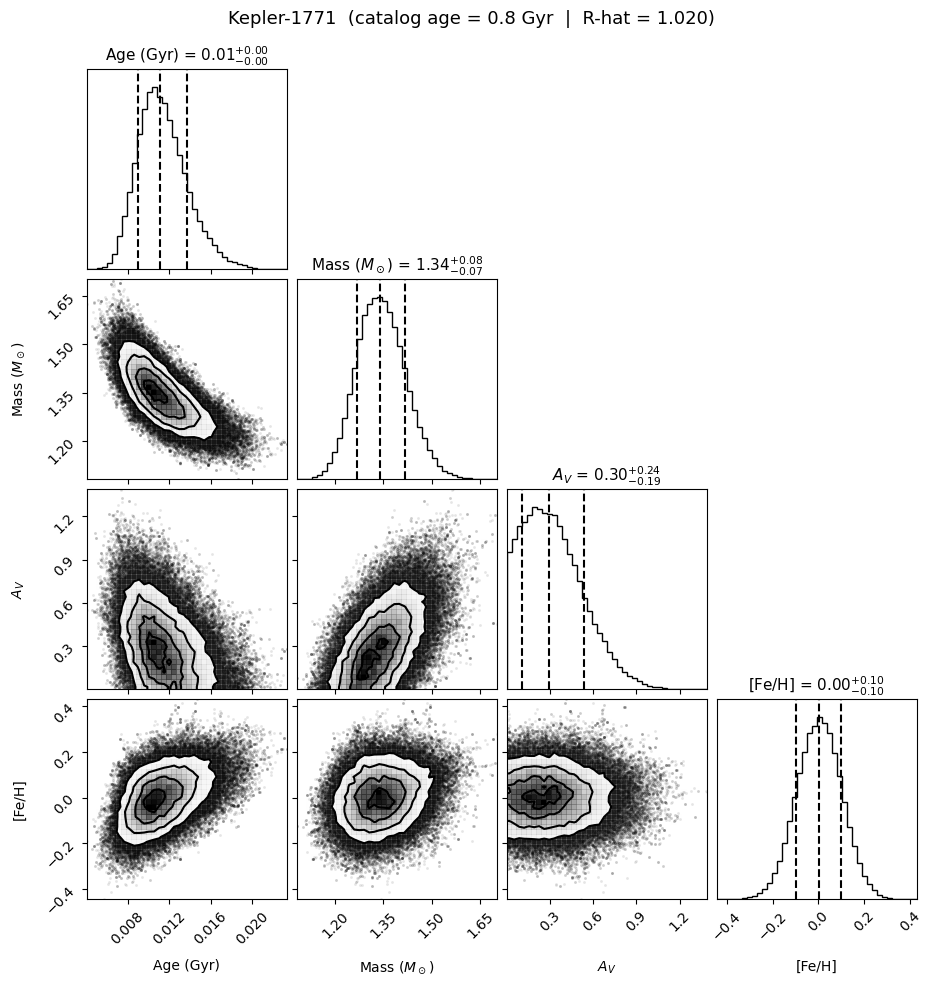

In [28]:
# re-run a single star to get its posterior samples for the corner plot
TARGET    = results_df[results_df["converged"]].sort_values("max_rhat").iloc[0]["hostname"]
star_row  = merged_sample[merged_sample["hostname"] == TARGET].iloc[0]
star      = row_to_star(star_row)

print(f"Re-running {TARGET} for corner plot...")
fit, samps = fit_star_emcee(star)
samps_plot = samps.copy()
samps_plot[:, 0] = 10 ** samps_plot[:, 0] / 1e9  # logage -> Gyr

cat_age = fit["age_catalog"]

import corner
fig = corner.corner(
    samps_plot,
    labels=["Age (Gyr)", r"Mass ($M_\odot$)", r"$A_V$", "[Fe/H]"],
    truths=[cat_age, None, None, None],
    truth_color="red",
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    bins=40,
)
fig.suptitle(
    f"{TARGET}  (catalog age = {cat_age:.1f} Gyr  |  R-hat = {fit['max_rhat']:.3f})",
    fontsize=13, y=1.02
)
plt.savefig(f"/Users/elenadickens/Desktop/ASTR_502/plots/corner_{TARGET.replace(' ','_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()